In [1]:
from selenium import webdriver
from selenium.webdriver.common.by import By
import pandas as pd
import time

In [3]:
driver = webdriver.Chrome()
driver.maximize_window()
driver.get("https://www.google.com")

In [4]:
driver.get('https://www.amazon.in')

In [5]:
search = driver.find_element(By.XPATH,'//*[@id="twotabsearchtextbox"]')
search.send_keys('Mobile phones')

In [6]:
c = driver.find_element(By.XPATH,'//*[@id="nav-search-submit-button"]')
c.click()

In [7]:
data =[]

In [8]:
products = driver.find_elements(By.XPATH,'//div[@data-component-type="s-search-result"]')
products
# len(products)

[<selenium.webdriver.remote.webelement.WebElement (session="e7fac4e43fed8129380de7aab1733dda", element="f.3D524D300358BEEE30AFA678332104F7.d.CDAAB87B3109AB7BAA7DDA9F67402584.e.4090")>,
 <selenium.webdriver.remote.webelement.WebElement (session="e7fac4e43fed8129380de7aab1733dda", element="f.3D524D300358BEEE30AFA678332104F7.d.CDAAB87B3109AB7BAA7DDA9F67402584.e.4091")>,
 <selenium.webdriver.remote.webelement.WebElement (session="e7fac4e43fed8129380de7aab1733dda", element="f.3D524D300358BEEE30AFA678332104F7.d.CDAAB87B3109AB7BAA7DDA9F67402584.e.4092")>,
 <selenium.webdriver.remote.webelement.WebElement (session="e7fac4e43fed8129380de7aab1733dda", element="f.3D524D300358BEEE30AFA678332104F7.d.CDAAB87B3109AB7BAA7DDA9F67402584.e.4093")>,
 <selenium.webdriver.remote.webelement.WebElement (session="e7fac4e43fed8129380de7aab1733dda", element="f.3D524D300358BEEE30AFA678332104F7.d.CDAAB87B3109AB7BAA7DDA9F67402584.e.4094")>,
 <selenium.webdriver.remote.webelement.WebElement (session="e7fac4e43fed812

In [9]:
for item in products:

# Product name
    try:
        product_name = item.find_element(By.XPATH,'.//h2/span').get_attribute("textContent").strip()
    except:
        product_name = None

# Price
    try:
        price = item.find_element(By.XPATH,'.//span[contains(@class,"a-price-whole")]').text.strip()
    except:
        price = None

# Discount
    try:
        discount = item.find_element(By.XPATH,'.//span[contains(text(),"%")]').text.strip()
    except:
        discount = None

# Rating
    try:
        rating = item.find_element(By.XPATH,'.//span[contains(@class,"a-icon-alt")]').get_attribute("textContent").strip()
    except:
        rating = None

# Brand name
    try:
        brand = product_name.split()[0]
    except:
        brand = None

# Review
    try:
        review = item.find_element(By.XPATH,'.//span[contains(@class,"s-underline-text")]').text.strip()
    except:
        review = None

# Deal
    try:
        deal = item.find_element(By.XPATH,'.//*[contains(text(),"deal") or contains(text(),"Deal")]').text.strip()
    except:
        deal = None

# Delivery
    try:
        delivery_text = item.find_element(By.XPATH,".//*[contains(@class,'a-color-base') and contains(.,'Delivery')]").text.strip()
    except:
        delivery_text = None

# URL
    try:
        product_url = item.find_element(By.XPATH, ".//a[contains(@href,'/dp/') or contains(@href,'/gp/product/')]").get_attribute("href")
    except:
        product_url = None

    data.append([product_name, price, discount, rating, brand, review, deal, delivery_text, product_url])

df = pd.DataFrame(data,columns=["Product Name", "Price", "Discount", "Rating", "Brand", "Review", "Deal", "Delivery", "URL"])

df

# df.to_excel("Amazon_products.xlsx", index=True)

# driver.quit()

,Product Name,Price,Discount,Rating,Brand,Review,Deal,Delivery,URL
0,"Apple iPhone Air 1 TB: Thinnest iPhone Ever, 1...","1,41,900",(11% off),4.6 out of 5 stars,Apple,(330),None,None,None
1,Apple iPhone 17 Pro Max 2 TB: 17.42 cm (6.9″) ...,"2,25,900",(2% off),4.6 out of 5 stars,Apple,(539),None,None,None
2,"Samsung Galaxy M07 Mobile (Black, 4GB RAM, 64G...","11,999",,4.2 out of 5 stars,Samsung,(2.1K),None,None,https://www.amazon.in/Samsung-Storage-MediaTek...
3,OnePlus N6x | 4GB+128GB | Burgundy Red | 7000m...,"20,999",(28% off),3.7 out of 5 stars,OnePlus,(44),None,None,https://www.amazon.in/OnePlus-48-Months-Smooth...
4,Apple iPhone 17 Pro 512 GB: 15.93 cm (6.3″) Di...,"1,50,900",(3% off),4.5 out of 5 stars,Apple,(595),None,None,None
5,"Lava Bold N2 5G (Regal Gold, 4GB RAM, 64GB Sto...","12,998",(19% off),3.9 out of 5 stars,Lava,(104),None,None,None
6,"Samsung Galaxy M17 5G Mobile (Sapphire Black, ...","19,999",(17% off),4.1 out of 5 stars,Samsung,(2.2K),None,None,https://www.amazon.in/Samsung-Sapphire-Storage...
7,"realme NARZO 80 Lite 4G (Obsidian Black 2026, ...","12,999","realme NARZO 80 Lite 4G (Obsidian Black 2026, ...",4.1 out of 5 stars,realme,(1.9K),None,None,https://www.amazon.in/realme-Obsidian-6300mAh-...
8,Redmi 15 5G Midnight Black 8GB + 256GB | Segme...,"25,498",(31% off),4.0 out of 5 stars,Redmi,(1.6K),None,None,https://www.amazon.in/Redmi-15-Midnight-Segmen...
9,OnePlus Nord CE6 Lite | 8GB+128GB | Hyper Blac...,"26,999",(21% off),4.4 out of 5 stars,OnePlus,(486),None,None,https://www.amazon.in/OnePlus-Segments-Dimensi...


# ---> Load data set

In [ ]:
df = pd.read_excel(r"Amazon_products.xlsx")

In [4]:
df

,Unnamed: 0,Product Name,Price,Discount,Rating,Brand,Review,Deal,Delivery,URL
0,0,OnePlus N6x | 4GB+64GB | Ice Blue | 7000mAh Ba...,"18,999",(30% off),NaN,OnePlus,NaN,Limited time deal,NaN,NaN
1,1,"Apple iPhone Air 1 TB: Thinnest iPhone Ever, 1...","1,41,900",(11% off),4.6 out of 5 stars,Apple,(331),NaN,NaN,NaN
2,2,"Samsung Galaxy M07 Mobile (Black, 4GB RAM, 64G...","11,499",NaN,4.2 out of 5 stars,Samsung,(2K),NaN,NaN,https://www.amazon.in/Samsung-Storage-MediaTek...
3,3,OnePlus N6x | 4GB+128GB | Burgundy Red | 7000m...,"20,999",(28% off),NaN,OnePlus,NaN,Limited time deal,NaN,https://www.amazon.in/OnePlus-48-Months-Smooth...
4,4,Apple iPhone 17 Pro 512 GB: 15.93 cm (6.3″) Di...,"1,50,900",(3% off),4.5 out of 5 stars,Apple,(594),NaN,NaN,NaN
5,5,Apple iPhone 17 Pro Max 256 GB: 17.42 cm (6.9″...,"1,43,990",(4% off),4.6 out of 5 stars,Apple,(536),NaN,NaN,NaN
6,6,"Motorola G57 Power 5G (Corsair, 8GB RAM, 128GB...","20,280",(8% off),4.3 out of 5 stars,Motorola,(786),NaN,NaN,https://www.amazon.in/Motorola-G57-Snapdragon-...
7,7,"Samsung Galaxy M36 5G Mobile (Serene Green, 6G...","19,999",(13% off),4.1 out of 5 stars,Samsung,(3.2K),NaN,NaN,https://www.amazon.in/Samsung-Storage-Enhanced...
8,8,"realme narzo 100 Lite 5G (Frost Silver,4GB+128...","17,499",(38% off),4.0 out of 5 stars,realme,(293),NaN,NaN,NaN
9,9,OnePlus Nord 6 | 8GB+256GB | Quick Silver | Sn...,"44,499",(16% off),4.3 out of 5 stars,OnePlus,(1.7K),Limited time deal,NaN,NaN


In [5]:
df.head()

,Unnamed: 0,Product Name,Price,Discount,Rating,Brand,Review,Deal,Delivery,URL
0,0,OnePlus N6x | 4GB+64GB | Ice Blue | 7000mAh Ba...,"18,999",(30% off),NaN,OnePlus,NaN,Limited time deal,NaN,NaN
1,1,"Apple iPhone Air 1 TB: Thinnest iPhone Ever, 1...","1,41,900",(11% off),4.6 out of 5 stars,Apple,(331),NaN,NaN,NaN
2,2,"Samsung Galaxy M07 Mobile (Black, 4GB RAM, 64G...","11,499",NaN,4.2 out of 5 stars,Samsung,(2K),NaN,NaN,https://www.amazon.in/Samsung-Storage-MediaTek...
3,3,OnePlus N6x | 4GB+128GB | Burgundy Red | 7000m...,"20,999",(28% off),NaN,OnePlus,NaN,Limited time deal,NaN,https://www.amazon.in/OnePlus-48-Months-Smooth...
4,4,Apple iPhone 17 Pro 512 GB: 15.93 cm (6.3″) Di...,"1,50,900",(3% off),4.5 out of 5 stars,Apple,(594),NaN,NaN,NaN


In [6]:
df.shape

(22, 10)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22 entries, 0 to 21
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Unnamed: 0    22 non-null     int64  
 1   Product Name  22 non-null     object 
 2   Price         21 non-null     object 
 3   Discount      19 non-null     object 
 4   Rating        20 non-null     object 
 5   Brand         22 non-null     object 
 6   Review        20 non-null     object 
 7   Deal          5 non-null      object 
 8   Delivery      0 non-null      float64
 9   URL           16 non-null     object 
dtypes: float64(1), int64(1), object(8)
memory usage: 1.8+ KB


In [8]:
df.columns

Index(['Unnamed: 0', 'Product Name', 'Price', 'Discount', 'Rating', 'Brand',
       'Review', 'Deal', 'Delivery', 'URL'],
      dtype='object')

# ----> Data Cleaning

## * Changing data type of columns

In [9]:
df.Price = df.Price.str.replace(",","")

In [10]:
df.Discount = df.Discount.astype(str).str.extract(r"(\d+(?:\.\d+)?)%")[0]

In [11]:
df.Rating = df.Rating.str.replace("out of 5 stars","")

In [12]:
df.Review = df.Review.str.replace(".","").str.replace("(","").str.replace(")","").str.replace("K","000")

In [13]:
# df["Price"]=df.Price.astype(int)
df["Discount"]=df.Discount.astype(float)
df["Review"]=df.Review.astype(float)
df["Rating"]=df.Rating.astype(float)

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22 entries, 0 to 21
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Unnamed: 0    22 non-null     int64  
 1   Product Name  22 non-null     object 
 2   Price         21 non-null     object 
 3   Discount      19 non-null     float64
 4   Rating        20 non-null     float64
 5   Brand         22 non-null     object 
 6   Review        20 non-null     float64
 7   Deal          5 non-null      object 
 8   Delivery      0 non-null      float64
 9   URL           16 non-null     object 
dtypes: float64(4), int64(1), object(5)
memory usage: 1.8+ KB


In [15]:
df.head()

,Unnamed: 0,Product Name,Price,Discount,Rating,Brand,Review,Deal,Delivery,URL
0,0,OnePlus N6x | 4GB+64GB | Ice Blue | 7000mAh Ba...,18999,30.0,NaN,OnePlus,NaN,Limited time deal,NaN,NaN
1,1,"Apple iPhone Air 1 TB: Thinnest iPhone Ever, 1...",141900,11.0,4.6,Apple,331.0,NaN,NaN,NaN
2,2,"Samsung Galaxy M07 Mobile (Black, 4GB RAM, 64G...",11499,NaN,4.2,Samsung,2000.0,NaN,NaN,https://www.amazon.in/Samsung-Storage-MediaTek...
3,3,OnePlus N6x | 4GB+128GB | Burgundy Red | 7000m...,20999,28.0,NaN,OnePlus,NaN,Limited time deal,NaN,https://www.amazon.in/OnePlus-48-Months-Smooth...
4,4,Apple iPhone 17 Pro 512 GB: 15.93 cm (6.3″) Di...,150900,3.0,4.5,Apple,594.0,NaN,NaN,NaN


## * Duplicate values

In [16]:
df.duplicated().sum()

np.int64(0)

## * Null values handling

In [17]:
df.drop(columns="Unnamed: 0",index=1,inplace=True)

In [18]:
df.isnull().sum()

Product Name     0
Price            1
Discount         3
Rating           2
Brand            0
Review           2
Deal            16
Delivery        21
URL              5
dtype: int64

In [19]:
(df.isnull().sum()/len(df))*100

Product Name      0.000000
Price             4.761905
Discount         14.285714
Rating            9.523810
Brand             0.000000
Review            9.523810
Deal             76.190476
Delivery        100.000000
URL              23.809524
dtype: float64

In [20]:
df.Price=df.Price.fillna("7699")

In [21]:
df["Price"]=df.Price.astype(int)

In [22]:
df.Discount = df.Discount.fillna(0)

In [23]:
df.Rating = df.Rating.fillna(df.Rating.median())

In [24]:
df.Review = df.Review.fillna(df.Review.median())

In [25]:
df.Deal = df.Deal.fillna("No deal")

In [26]:
df.Delivery = df.Delivery.fillna("Not available")

In [27]:
df.URL = df.URL.fillna("Not available")

In [28]:
df.isnull().sum()

Product Name    0
Price           0
Discount        0
Rating          0
Brand           0
Review          0
Deal            0
Delivery        0
URL             0
dtype: int64

# ----> Data filtering

In [29]:
df[df.Price.between(30000,80000)]

,Product Name,Price,Discount,Rating,Brand,Review,Deal,Delivery,URL
9,OnePlus Nord 6 | 8GB+256GB | Quick Silver | Sn...,44499,16.0,4.3,OnePlus,17000.0,Limited time deal,Not available,Not available
19,"Samsung Galaxy A56 5G (Awesome Olive, 8GB, 256...",35999,32.0,4.3,Samsung,373.0,No deal,Not available,https://www.amazon.in/Samsung-Galaxy-Awesome-G...


In [30]:
df[(df.Discount>30) & (df.Rating>2.5)]

,Product Name,Price,Discount,Rating,Brand,Review,Deal,Delivery,URL
8,"realme narzo 100 Lite 5G (Frost Silver,4GB+128...",17499,38.0,4.0,realme,293.0,No deal,Not available,Not available
11,"realme NARZO 90x 5G (Flash Blue 2026, 6GB+128G...",19499,400.0,4.2,realme,13000.0,No deal,Not available,https://www.amazon.in/realme-7000mAh-Biggest-B...
12,"REDMI A7 Pro 5G (Black, 4GB RAM,128GB Storage)...",15499,45.0,3.4,REDMI,16000.0,No deal,Not available,https://www.amazon.in/REDMI-A7-Pro-5G-Processo...
13,REDMI 15 5G Frosted White 8GB + 256GB | Segmen...,25499,31.0,4.0,REDMI,16000.0,No deal,Not available,https://www.amazon.in/Redmi-Segments-7000mAhA-...
14,"REDMI A7 Pro 5G (Mist Blue, 4GB RAM,128GB Stor...",15499,45.0,3.4,REDMI,16000.0,No deal,Not available,https://www.amazon.in/Storage-Segments-Fastest...
19,"Samsung Galaxy A56 5G (Awesome Olive, 8GB, 256...",35999,32.0,4.3,Samsung,373.0,No deal,Not available,https://www.amazon.in/Samsung-Galaxy-Awesome-G...
20,"realme NARZO 80 Lite 4G (Obsidian Black 2026, ...",12999,300.0,4.1,realme,19000.0,No deal,Not available,https://www.amazon.in/realme-Obsidian-6300mAh-...
21,"iQOO Z10 Lite 5G (Titanium Blue 2026, 4GB RAM,...",16999,39.0,4.1,iQOO,242.0,No deal,Not available,https://www.amazon.in/iQOO-Titanium-Dimensity-...


In [31]:
df[df.Brand=="Apple"]

,Product Name,Price,Discount,Rating,Brand,Review,Deal,Delivery,URL
4,Apple iPhone 17 Pro 512 GB: 15.93 cm (6.3″) Di...,150900,3.0,4.5,Apple,594.0,No deal,Not available,Not available
5,Apple iPhone 17 Pro Max 256 GB: 17.42 cm (6.9″...,143990,4.0,4.6,Apple,536.0,No deal,Not available,Not available


In [32]:
df[(df.Price>80000) | (df.Brand=="OnePlus")]

,Product Name,Price,Discount,Rating,Brand,Review,Deal,Delivery,URL
0,OnePlus N6x | 4GB+64GB | Ice Blue | 7000mAh Ba...,18999,30.0,4.1,OnePlus,786.0,Limited time deal,Not available,Not available
3,OnePlus N6x | 4GB+128GB | Burgundy Red | 7000m...,20999,28.0,4.1,OnePlus,786.0,Limited time deal,Not available,https://www.amazon.in/OnePlus-48-Months-Smooth...
4,Apple iPhone 17 Pro 512 GB: 15.93 cm (6.3″) Di...,150900,3.0,4.5,Apple,594.0,No deal,Not available,Not available
5,Apple iPhone 17 Pro Max 256 GB: 17.42 cm (6.9″...,143990,4.0,4.6,Apple,536.0,No deal,Not available,Not available
9,OnePlus Nord 6 | 8GB+256GB | Quick Silver | Sn...,44499,16.0,4.3,OnePlus,17000.0,Limited time deal,Not available,Not available


# ----> Data methods

In [33]:
# sorting
df.sort_values(by="Price",ascending = False).head()

,Product Name,Price,Discount,Rating,Brand,Review,Deal,Delivery,URL
4,Apple iPhone 17 Pro 512 GB: 15.93 cm (6.3″) Di...,150900,3.0,4.5,Apple,594.0,No deal,Not available,Not available
5,Apple iPhone 17 Pro Max 256 GB: 17.42 cm (6.9″...,143990,4.0,4.6,Apple,536.0,No deal,Not available,Not available
9,OnePlus Nord 6 | 8GB+256GB | Quick Silver | Sn...,44499,16.0,4.3,OnePlus,17000.0,Limited time deal,Not available,Not available
19,"Samsung Galaxy A56 5G (Awesome Olive, 8GB, 256...",35999,32.0,4.3,Samsung,373.0,No deal,Not available,https://www.amazon.in/Samsung-Galaxy-Awesome-G...
13,REDMI 15 5G Frosted White 8GB + 256GB | Segmen...,25499,31.0,4.0,REDMI,16000.0,No deal,Not available,https://www.amazon.in/Redmi-Segments-7000mAhA-...


In [34]:
# summary
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Price,21.0,31240.571429,39514.691794,7699.0,15499.0,17499.0,20999.0,150900.0
Discount,21.0,50.619048,101.931093,0.0,4.0,16.0,38.0,400.0
Rating,21.0,4.047619,0.299364,3.4,3.9,4.1,4.2,4.6
Review,21.0,7315.285714,9443.841025,6.0,453.0,786.0,16000.0,32000.0


In [35]:
# count values
df.value_counts("Brand")

Brand
Samsung     6
OnePlus     3
REDMI       3
realme      3
Apple       2
Lava        1
Motorola    1
Zeno        1
iQOO        1
Name: count, dtype: int64

# ----> Creating bins and groups

In [36]:
df['Brand_group']=pd.cut(x=df.Price, bins=[0,20000,50000,100000,200000],labels=["Low","Medium","High","Super high"])
df.head()

,Product Name,Price,Discount,Rating,Brand,Review,Deal,Delivery,URL,Brand_group
0,OnePlus N6x | 4GB+64GB | Ice Blue | 7000mAh Ba...,18999,30.0,4.1,OnePlus,786.0,Limited time deal,Not available,Not available,Low
2,"Samsung Galaxy M07 Mobile (Black, 4GB RAM, 64G...",11499,0.0,4.2,Samsung,2000.0,No deal,Not available,https://www.amazon.in/Samsung-Storage-MediaTek...,Low
3,OnePlus N6x | 4GB+128GB | Burgundy Red | 7000m...,20999,28.0,4.1,OnePlus,786.0,Limited time deal,Not available,https://www.amazon.in/OnePlus-48-Months-Smooth...,Medium
4,Apple iPhone 17 Pro 512 GB: 15.93 cm (6.3″) Di...,150900,3.0,4.5,Apple,594.0,No deal,Not available,Not available,Super high
5,Apple iPhone 17 Pro Max 256 GB: 17.42 cm (6.9″...,143990,4.0,4.6,Apple,536.0,No deal,Not available,Not available,Super high


# ----> Accessing

In [37]:
df[["Product Name","Price","URL"]].head()

,Product Name,Price,URL
0,OnePlus N6x | 4GB+64GB | Ice Blue | 7000mAh Ba...,18999,Not available
2,"Samsung Galaxy M07 Mobile (Black, 4GB RAM, 64G...",11499,https://www.amazon.in/Samsung-Storage-MediaTek...
3,OnePlus N6x | 4GB+128GB | Burgundy Red | 7000m...,20999,https://www.amazon.in/OnePlus-48-Months-Smooth...
4,Apple iPhone 17 Pro 512 GB: 15.93 cm (6.3″) Di...,150900,Not available
5,Apple iPhone 17 Pro Max 256 GB: 17.42 cm (6.9″...,143990,Not available


In [38]:
df.loc[10:15,["Product Name","Price"]]

,Product Name,Price
10,"Samsung Galaxy M06 5G Mobile (Blazing Black, 6...",15999
11,"realme NARZO 90x 5G (Flash Blue 2026, 6GB+128G...",19499
12,"REDMI A7 Pro 5G (Black, 4GB RAM,128GB Storage)...",15499
13,REDMI 15 5G Frosted White 8GB + 256GB | Segmen...,25499
14,"REDMI A7 Pro 5G (Mist Blue, 4GB RAM,128GB Stor...",15499
15,Zeno 100 Lite | UNISOC Octa-Core Processor | 2...,7699


In [39]:
df.iloc[10:15,[0,1,9]]

,Product Name,Price,Brand_group
11,"realme NARZO 90x 5G (Flash Blue 2026, 6GB+128G...",19499,Low
12,"REDMI A7 Pro 5G (Black, 4GB RAM,128GB Storage)...",15499,Low
13,REDMI 15 5G Frosted White 8GB + 256GB | Segmen...,25499,Medium
14,"REDMI A7 Pro 5G (Mist Blue, 4GB RAM,128GB Stor...",15499,Low
15,Zeno 100 Lite | UNISOC Octa-Core Processor | 2...,7699,Low


# ----> Group by

In [40]:
# Average price of each brand
df[["Brand","Price"]].groupby("Brand").mean().reset_index()

,Brand,Price
0,Apple,147445.000000
1,Lava,9699.000000
2,Motorola,20280.000000
3,OnePlus,28165.666667
4,REDMI,18832.333333
5,Samsung,19249.000000
6,Zeno,7699.000000
7,iQOO,16999.000000
8,realme,16665.666667


In [41]:
# maximum discount given by each brand
df[["Brand","Discount"]].groupby("Brand").max().reset_index().sort_values(by="Discount",ascending=False)

,Brand,Discount
8,realme,400.0
4,REDMI,45.0
7,iQOO,39.0
5,Samsung,32.0
3,OnePlus,30.0
2,Motorola,8.0
0,Apple,4.0
1,Lava,3.0
6,Zeno,0.0


In [42]:
# Highest rating of every brand (out of 5)
df[["Brand","Rating"]].groupby("Brand").max().reset_index().sort_values(by="Rating",ascending=False)

,Brand,Rating
0,Apple,4.6
2,Motorola,4.3
3,OnePlus,4.3
5,Samsung,4.3
8,realme,4.2
7,iQOO,4.1
4,REDMI,4.0
6,Zeno,3.9
1,Lava,3.8


# ----> Vizualization

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

## * Histogram from numeric columns

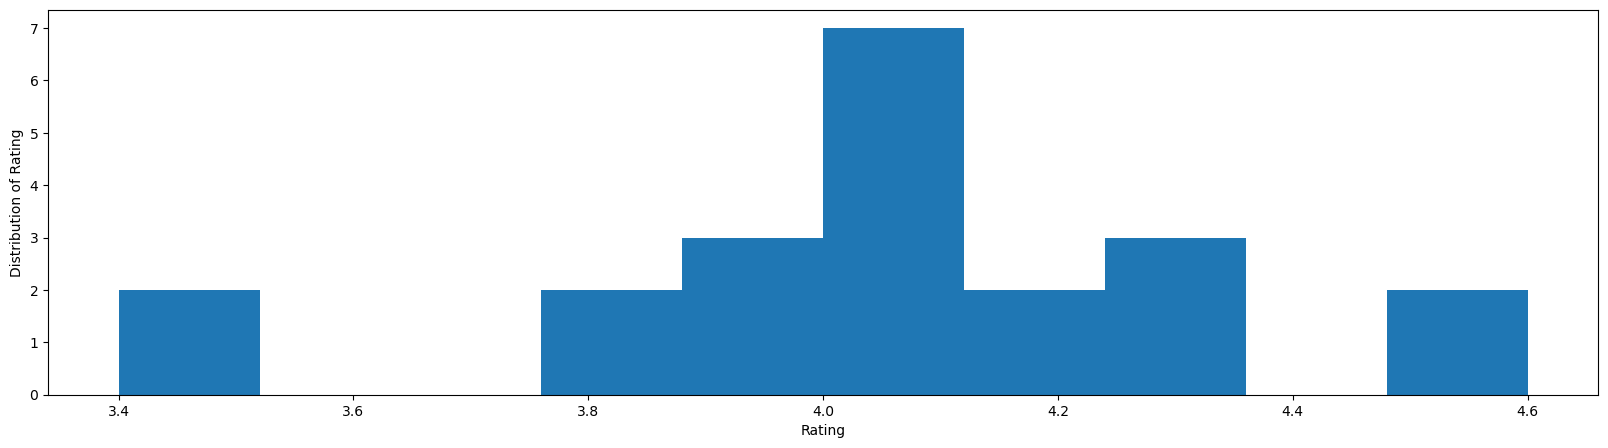

In [48]:
plt.figure(figsize=(20,5))
df.Rating.plot(kind='hist')
plt.xlabel('Rating')
plt.ylabel('Distribution of Rating')
plt.show()

In [66]:
cont_df=df.select_dtypes(include='number')
cont_df.columns

Index(['Price', 'Discount', 'Rating', 'Review'], dtype='object')

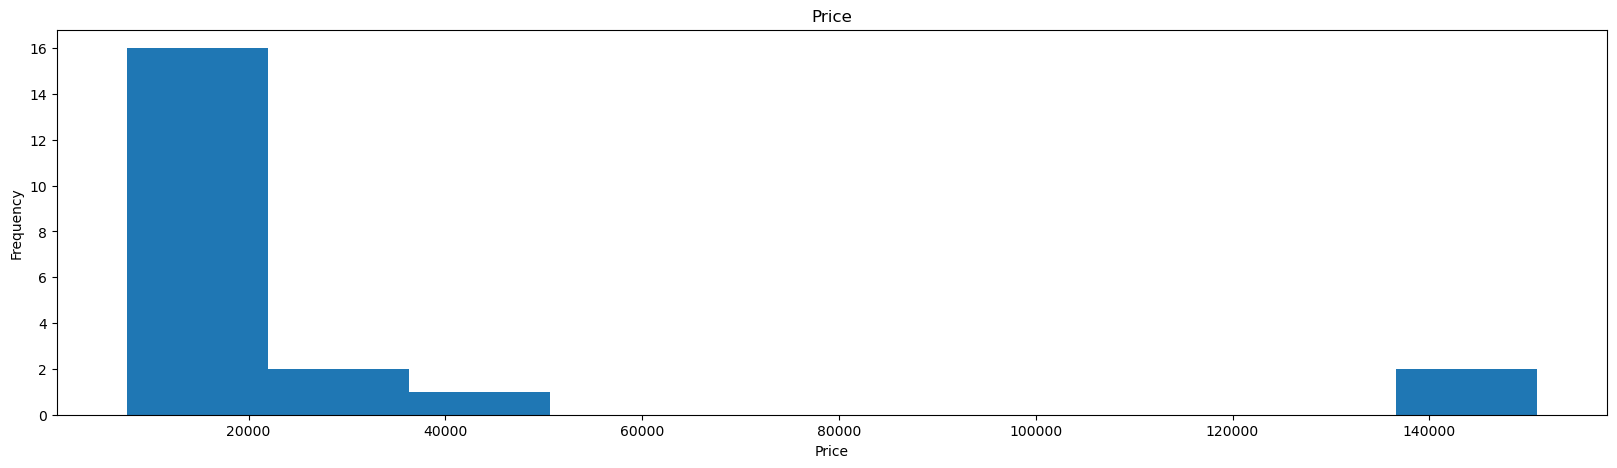

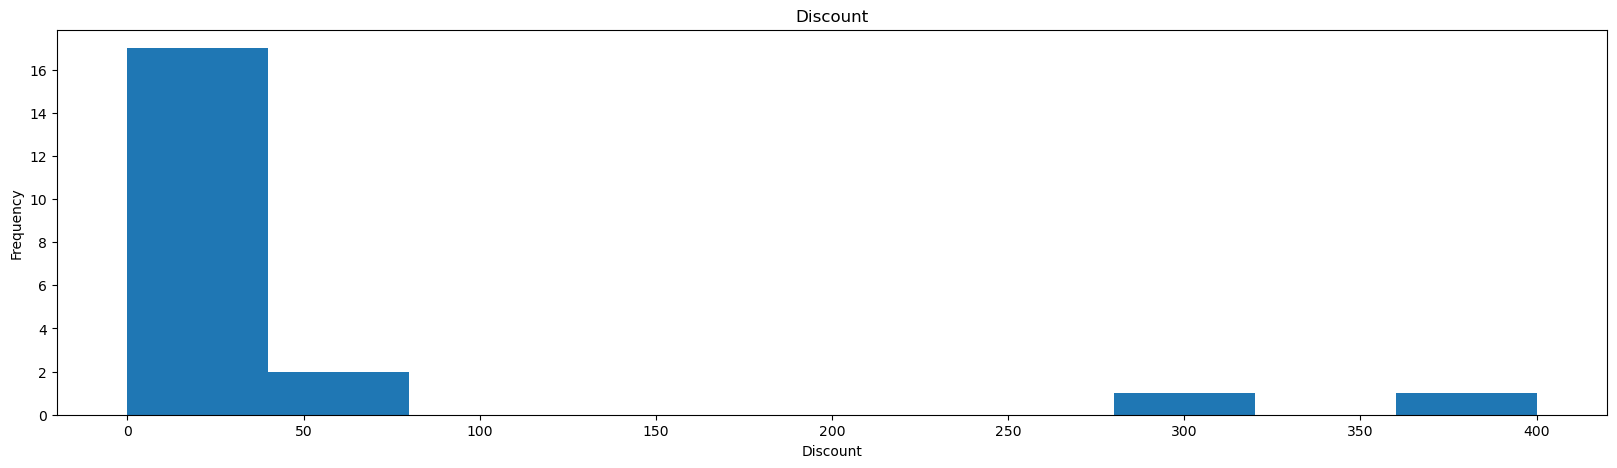

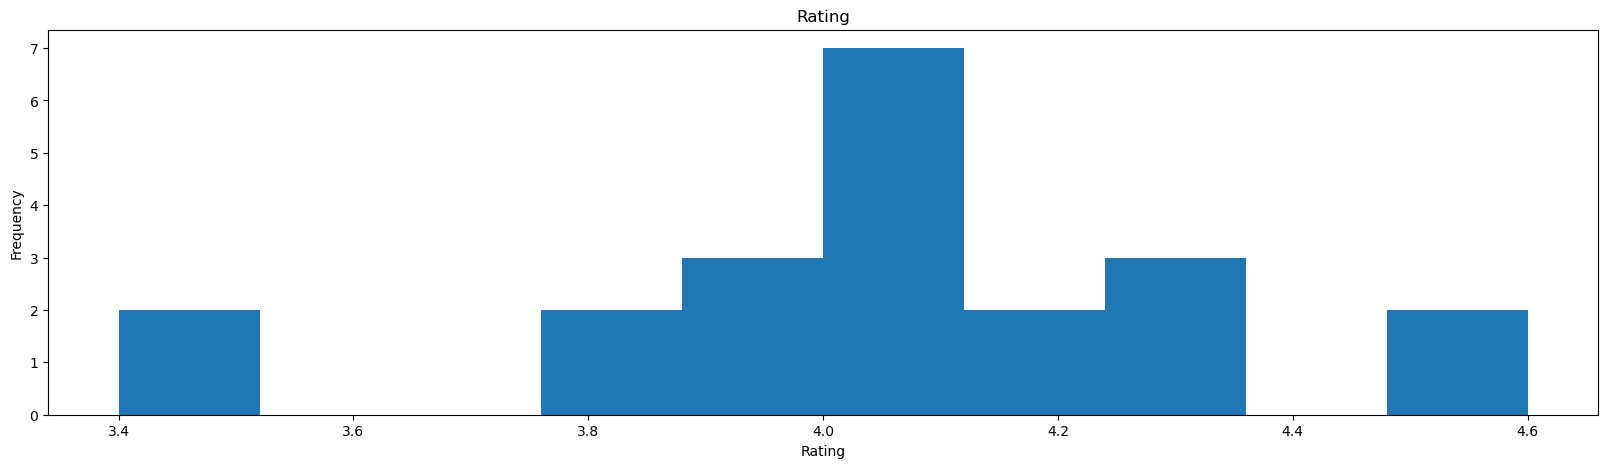

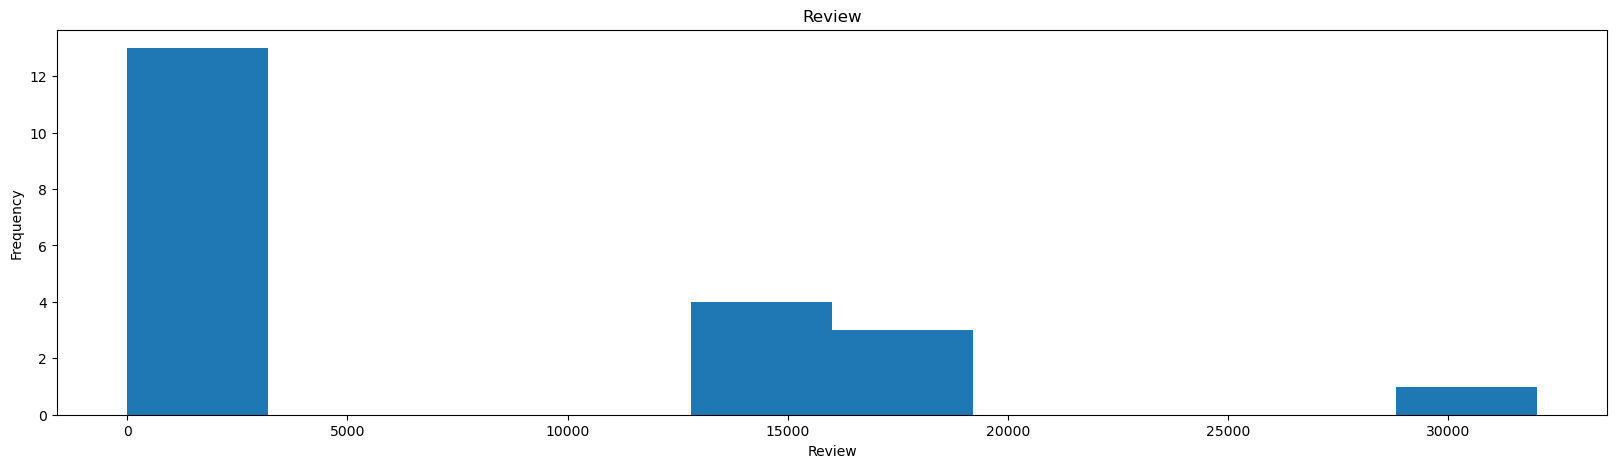

In [56]:
for i in cont_df.columns:
    plt.figure(figsize=(20,5))
    df[i].plot(kind='hist')
    plt.title(i)
    plt.xlabel(i)
    plt.show()

## -->Pie chart and Barchart for categorical columns

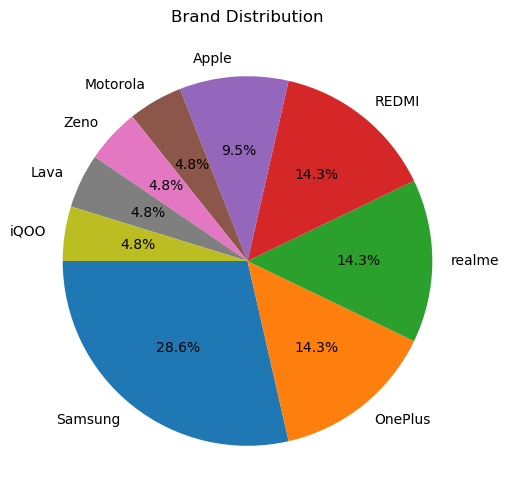

In [52]:
df['Brand'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=180,
    figsize=(6,6)
)

plt.title("Brand Distribution")
plt.ylabel("")
plt.show()

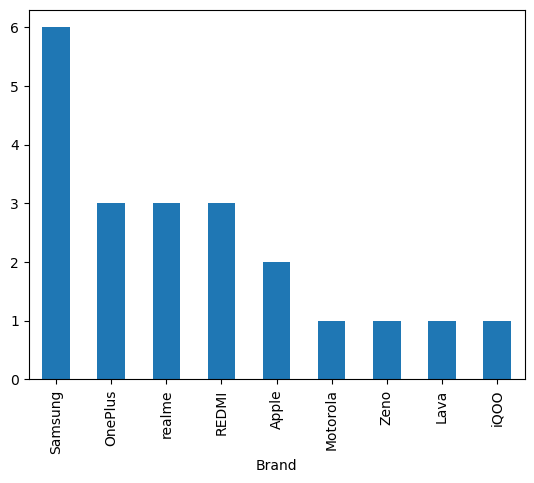

C:\Users\BAPS\AppData\Local\Temp\ipykernel_11696\527911216.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df,x='Brand',palette='Set3')


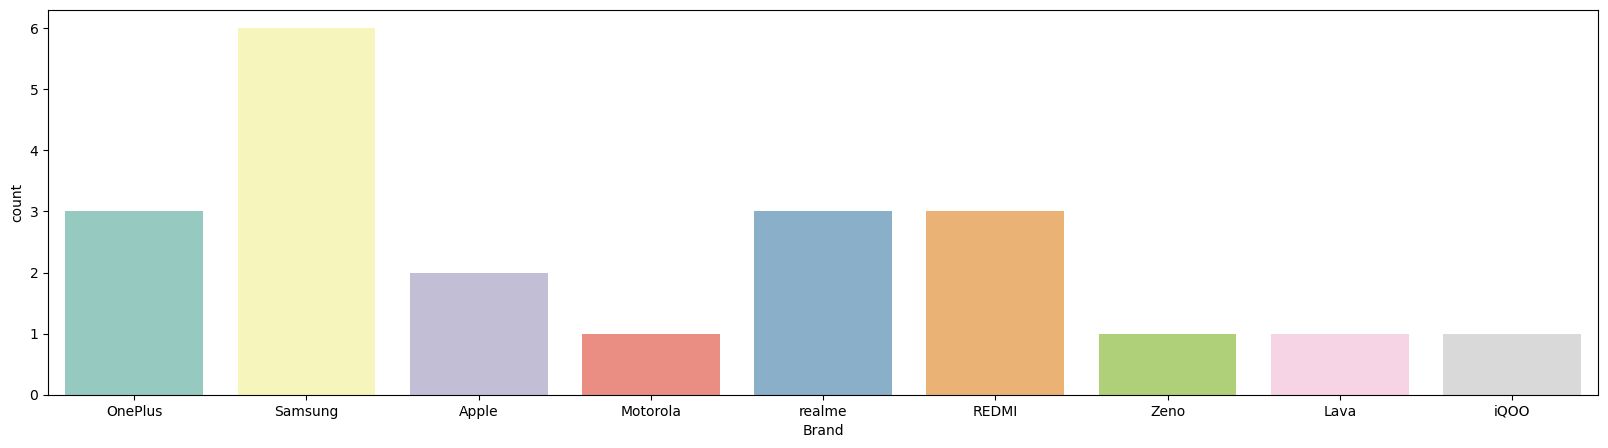

In [53]:
df.Brand.value_counts().plot(kind='bar')
plt.show()

plt.figure(figsize=(20,5))
sns.countplot(data=df,x='Brand',palette='Set3')
plt.show()

## --> Scatter plot for both numeric columns

<Axes: xlabel='Price', ylabel='Discount'>

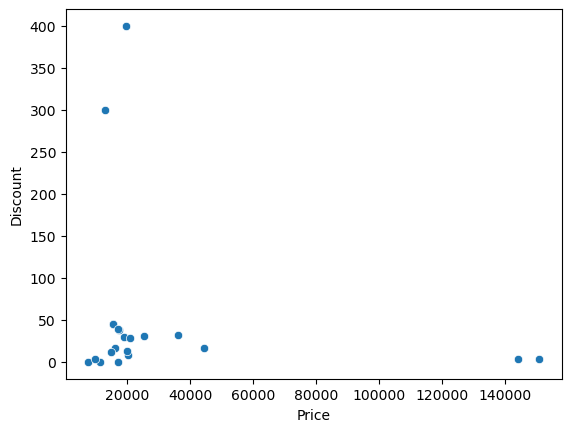

In [58]:
sns.scatterplot(data=df,x='Price',y='Discount')

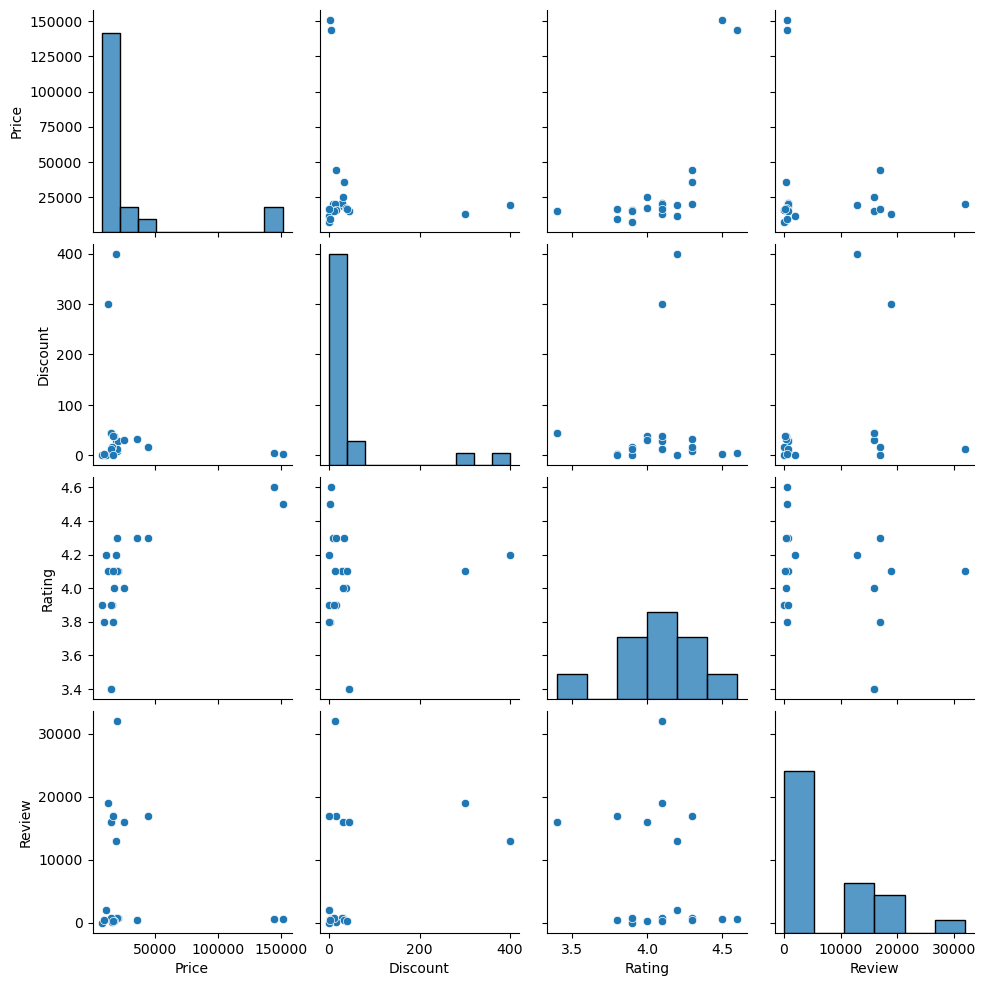

In [59]:
sns.pairplot(cont_df)

## --> Heatmap

             Price  Discount    Rating    Review
Price     1.000000 -0.162103  0.626529 -0.192073
Discount -0.162103  1.000000  0.055188  0.303696
Rating    0.626529  0.055188  1.000000 -0.278291
Review   -0.192073  0.303696 -0.278291  1.000000


<Axes: >

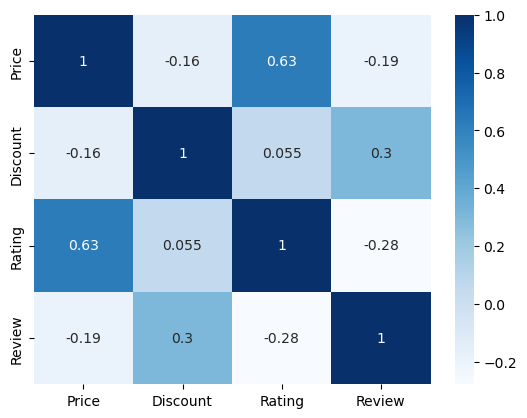

In [67]:
cont_df=cont_df[["Price","Discount","Rating","Review"]]
cor_df=cont_df.corr()
print(cor_df)
sns.heatmap(data=cor_df,annot=True,cmap='Blues')

# ----> Outliers

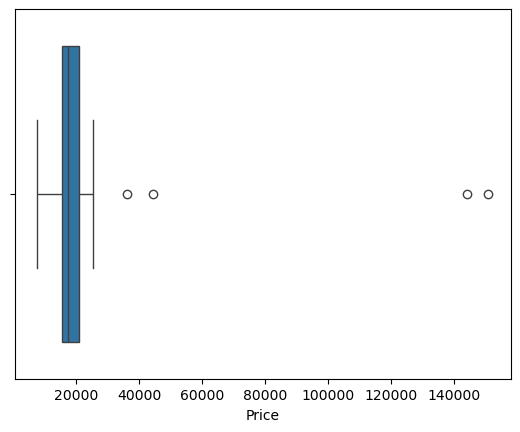

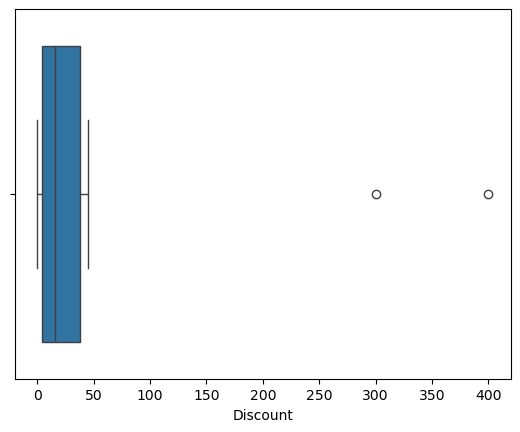

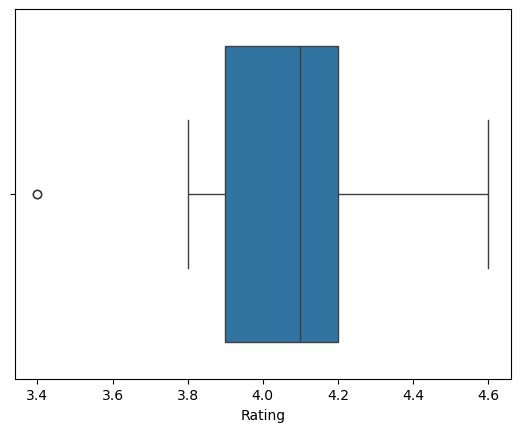

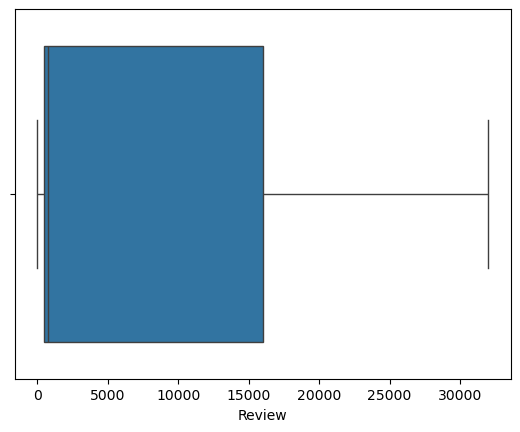

In [68]:
for i in cont_df.columns:
    sns.boxplot(data=df,x=i)
    plt.show()

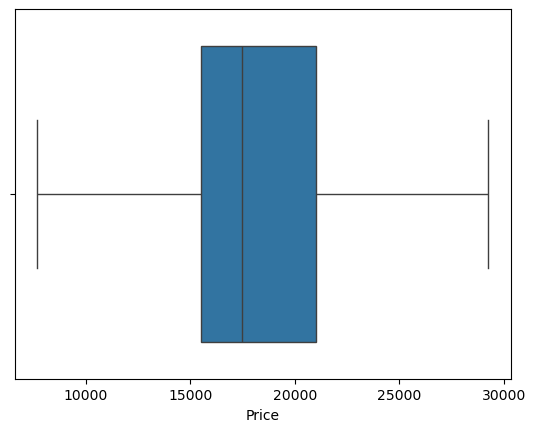

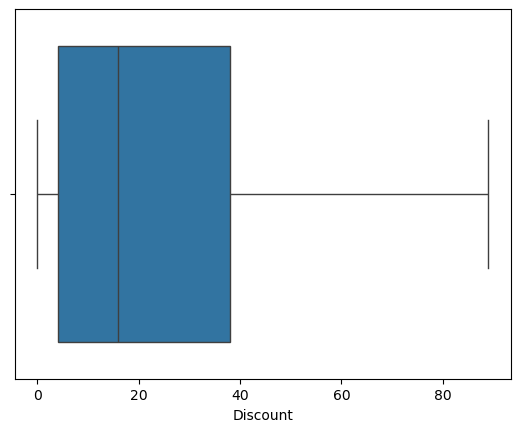

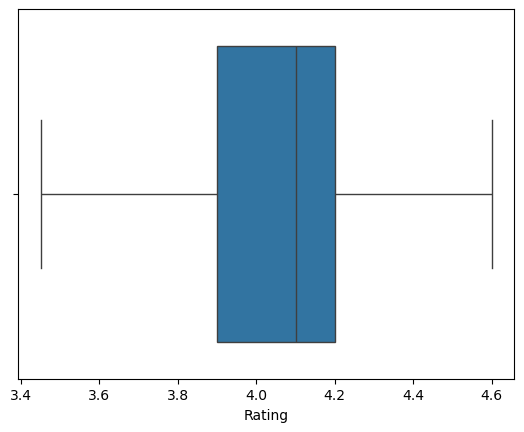

In [73]:
for i in ['Price','Discount','Rating']:
    q1 = df[i].quantile(0.25)
    q3 = df[i].quantile(0.75)
    iqr = q3-q1
    lr=q1-1.5*iqr
    ur=q3+1.5*iqr
    df[i].clip(lower=lr,upper=ur,inplace=True)
    sns.boxplot(data=df,x=i)
    plt.show()

## ---> one categorical and one numeric column

<Axes: xlabel='Brand', ylabel='Price'>

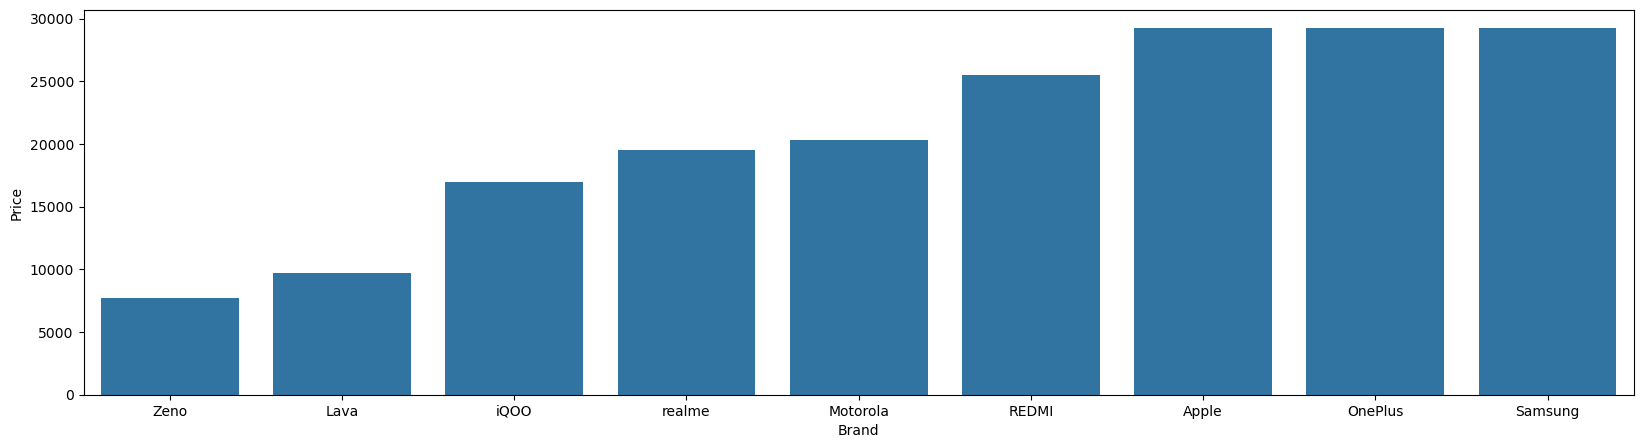

In [75]:
cont_cat_df=df[['Brand','Price']].groupby(by='Brand').max().reset_index().sort_values(by='Price',ascending=True)
plt.figure(figsize=(20,5))
sns.barplot(data=cont_cat_df,x='Brand',y='Price')